# How can a processor see momentum?

This is a companion notebook to my latest blog post. It uses statsbomb's free event data for the 2022 world cup to see if we can measure "momentum" using different ways: 

1. **Territory**: who has the ball, and where
2. **Threat**: how dangerous that possession is (xG and expected threat, xT)
3. **Intensity**: how hard each team presses
4. **Dynamics**: does being on top make you more likely to stay on top?
5. **Outcomes**: what happens after a goal, or even a red gard

This dashborad follows the England v France (2022 quarter-final game); safe to say, I liked the recent 3rd place match more. Regardless, the tests in this 

Run the cells in order. The first run downloads all 64 matches (a few minutes) and caches them, so later runs are quick. Every figure is shown inline and saved to `./figures`.

requirements: 
    **Run** once if you don't have these installed
    pip install statsbombpy pandas numpy matplotlib

In [33]:
import warnings
from pathlib import Path as path_

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import PowerNorm
import numpy as np
import pandas as pd
from statsbombpy import sb

warnings.filterwarnings("ignore", message="credentials were not supplied")
%matplotlib inline

cache_ = path_("data/wc2022_events.pkl")
out_ = path_("figures")
out_.mkdir(exist_ok=True)

# I came back to this and found it appropriate to use the colours of teams
team_colours = {"England": "r", "France": "b"}
rng_ = np.random.default_rng(2022)       # fixed seed, so the simulations are reproducible

period_end = {1: 45, 2: 90, 3: 105, 4: 120}
nx, ny = 16, 12

## 2. Load the data

`statsbombpy` downloads every event (pass, carry, shot, pressure...) from all 64 matches. We only keep the columns we need and cache the result as a pickle so we don't download it again.

In [5]:
def load_events() -> pd.DataFrame:
    # all 64 matches, downloaded once and cached as a pickle.
    if cache_.exists():
        return pd.read_pickle(cache_)

    """ 
    I would like to make this easier in the future where you can just choose 
    what tournament you'd like and what division, season, gender, I do this this is fine
    but I feel like it needs to me more generalised

    """
    ev = sb.competition_events(country="International", division="FIFA World Cup", 
                               season="2022", gender="male")
    
    keep = ["id", "match_id", "period", "minute", "second", "type", "team",
            "possession", "location", "pass_end_location", "pass_outcome",
            "carry_end_location", "shot_statsbomb_xg", "shot_outcome", "shot_type"]
    ev = ev[keep].copy()
    for col in ["location", "pass_end_location", "carry_end_location"]:
        ev[col] = ev[col].apply(lambda v: list(v) if isinstance(v, (list, np.ndarray)) else None)
    cache_.parent.mkdir(exist_ok=True)
    ev.to_pickle(cache_)
    return ev

raw = load_events()

print(f"{len(raw):,} events across {raw['match_id'].nunique()} matches")
raw.head()

234,637 events across 64 matches


,id,match_id,period,minute,second,type,team,possession,location,pass_end_location,pass_outcome,carry_end_location,shot_statsbomb_xg,shot_outcome,shot_type
0,1f60fe1e-0340-49e2-975e-f16f54c5da1a,3857276,1,0,0,Starting XI,Canada,1,None,None,NaN,None,NaN,NaN,NaN
1,d5ffdab0-a19a-497e-a0f6-d5403bfcc2b5,3857276,1,0,0,Starting XI,Morocco,1,None,None,NaN,None,NaN,NaN,NaN
2,a5b61357-d2e3-4d02-bb2a-efd246e0c349,3857271,1,0,0,Starting XI,England,1,None,None,NaN,None,NaN,NaN,NaN
3,d1894546-996a-4256-b7fa-0203b589265d,3857271,1,0,0,Starting XI,Iran,1,None,None,NaN,None,NaN,NaN,NaN
4,2bd3397b-74c3-493e-9d91-d036197462ee,3857296,1,0,0,Starting XI,Croatia,1,None,None,NaN,None,NaN,NaN,NaN


## 3. Stitch match clock

StatsBomb restarts the clock at 45:00 for the second half, so first-half stoppage time (e.g. 45:00 to 48:30) would overlap the start of the second half. We shift each period by however much stoppage time came before it, giving one continuous clock `t` per match. We also drop period 5 (the penalty shootout).

`tmin` is `t` rounded down to a whole minute, which is what we group by later.

In [6]:
def add_clock(ev: pd.DataFrame) -> pd.DataFrame:
    ev = ev[ev["period"] <= 4].copy()
    ev["t"] = ev["minute"] + ev["second"]/60
    shifts = []
    for _, m in ev.groupby("match_id"):
        total, shift = 0.0, {}
        for p in (1, 2, 3, 4):
            shift[p] = total
            tp = m.loc[m["period"] == p, "t"]
            if len(tp):
                total += max(tp.max() - period_end[p], 0)
        shifts.append(m["period"].map(shift))
    ev["t"]   += pd.concat(shifts)
    ev["tmin"] = ev["t"].astype(int)
    return ev

ev = add_clock(raw)
ev[["match_id", "period", "minute", "second", "t", "tmin", "type", "team"]].head()

,match_id,period,minute,second,t,tmin,type,team
0,3857276,1,0,0,0.0,0,Starting XI,Canada
1,3857276,1,0,0,0.0,0,Starting XI,Morocco
2,3857271,1,0,0,0.0,0,Starting XI,England
3,3857271,1,0,0,0.0,0,Starting XI,Iran
4,3857296,1,0,0,0.0,0,Starting XI,Croatia


## 4. Expected threat (xT): a possession value model

xG (expected goals) only scores shots, and shots are rare. **Expected threat** ([Karun Singh's xT](https://karun.in/blog/expected-threat.html)) gives every zone of the pitch a value: the probability of scoring from there within the next few actions.

We cut the pitch into a 16 × 12 grid. From each cell, a team either shoots or moves the ball (pass or carry). So the value of a cell is:

$$xT(\text{cell}) = P(\text{shoot}) \cdot P(\text{goal} \mid \text{shoot}) + P(\text{move}) \sum_{\text{cells}'} P(\text{cell} \to \text{cell}') \cdot xT(\text{cell}')$$

The value depends on itself, so we solve it by iterating: start from zero and apply the formula 30 times, each pass letting value flow one more action back up the pitch. Penalties are excluded because they don't come from open play.

First, two helpers: `xy` turns the `[x, y]` location lists into arrays, and `cell` maps coordinates to a grid-cell number.

In [7]:
def xy(series: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    arr = np.array([v if v is not None else [np.nan, np.nan] for v in series], dtype=float)
    return arr[:, 0], arr[:, 1]

def cell(x, y):
    ix = np.clip((x/120 * nx).astype(int), 0, nx-1)
    iy = np.clip((y/80  * ny).astype(int), 0, ny-1)
    return ix * ny + iy

def fit_xt(ev: pd.DataFrame, n_iter: int = 30) -> np.ndarray:
    n = nx*ny
    passes  = ev[ev["type"]  == "Pass"]
    carries = ev[ev["type"]  == "Carry"]
    shots   = ev[(ev["type"] == "Shot") & (ev["shot_type"] != "Penalty")]

    # shots and goals from each cell
    sx, sy     = xy(shots["location"])
    shot_cells = cell(sx, sy)
    n_shots = np.bincount(shot_cells, minlength=n)
    n_goals = np.bincount(shot_cells[(shots["shot_outcome"] == "Goal").values], minlength=n)

    # moves (passes + carries): where they start and end, and whether they succeeded
    px, py   = xy(passes["location"])
    ex, ey   = xy(passes["pass_end_location"])
    cx, cy   = xy(carries["location"])
    cex, cey = xy(carries["carry_end_location"])
    
    start   = np.concatenate([cell(px, py), cell(cx, cy)])
    end     = np.concatenate([cell(ex, ey), cell(cex, cey)])
    success = np.concatenate([passes["pass_outcome"].isna().values, np.ones(len(carries), bool)])
    n_moves = np.bincount(start, minlength=n)

    # transition matrix: P(successful move from cell i ends in cell j)
    # failed moves lose the ball, so they contribute zero value.
    trans = np.zeros((n, n))
    np.add.at(trans, (start[success], end[success]), 1)
    trans /= np.maximum(n_moves, 1)[:, None]

    total = n_shots + n_moves
    p_shot = n_shots/np.maximum(total, 1)
    p_move = n_moves/np.maximum(total, 1)
    p_goal = n_goals/np.maximum(n_shots, 1)

    xt = np.zeros(n)
    for _ in range(n_iter):
        xt = p_shot*p_goal + p_move*trans @ xt
    return xt

xt = fit_xt(ev)
print(f"xT ranges from {xt.min():.4f} to {xt.max():.3f}")


xT ranges from 0.0009 to 0.343


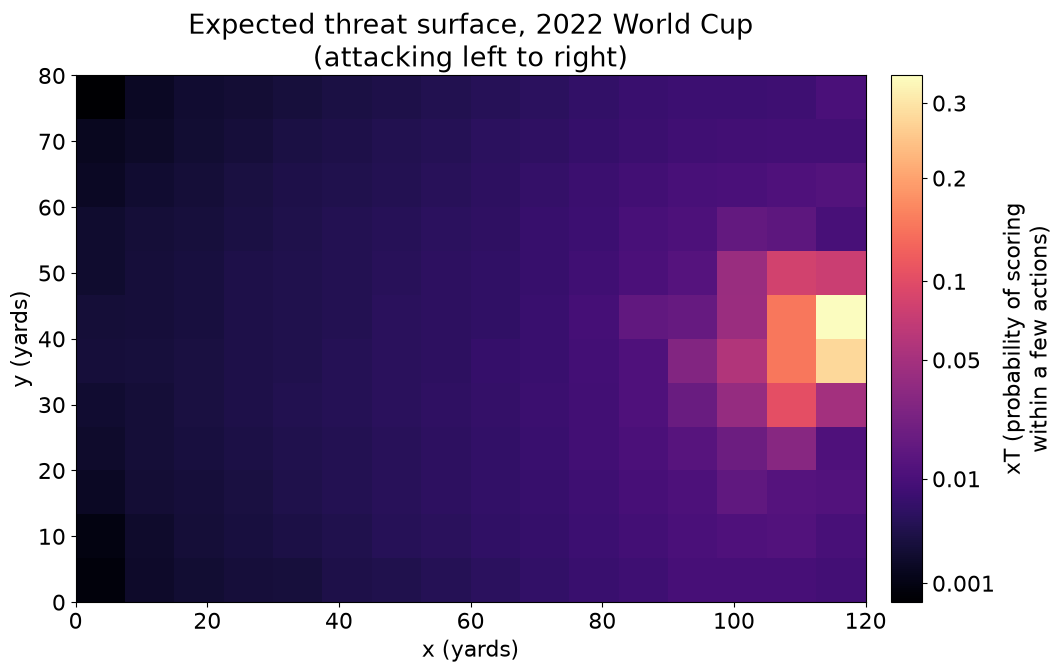

In [20]:
"""
    Let's look at the surface. It's near zero in a team's own half and rises sharply 
    close to goal (the colour scale is compressed so you can see detail away from goal).

    just a quick note about my plotting scripts, normally I'd like to have them all in
    nice computer modern font, but i appreciate that people might not have them installed,
    but if you'd like to here are the settings:

    # ------------------------------------------------------------------------------
    # plot parameters
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.sans-serif": ["Computer Modern Roman"]})
        
    # for Palatino and other serif fonts use:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
    })
    
    # It's also possible to use the reduced notation by directly setting font.family:
    plt.rcParams.update({
      "text.usetex": True,
      "font.family": "Computer Modern Roman"
    })

"""
# plot stuff -----------------------------------------------------------------------------
fig01, axs01 = plt.subplots(1, 1, figsize=(12, 7))
fontssize = 14

im = axs01.imshow(xt.reshape(nx, ny).T, origin="lower", extent=(0, 120, 0, 80), cmap="magma",
                  norm=PowerNorm(gamma=0.4))

# Colour bar axis attached to the plot, so it is always exactly as tall as the pitch
divider = make_axes_locatable(axs01)
cax = divider.append_axes("right", size="4%", pad=0.25)
fig01.colorbar(im, cax=cax, ticks=[0.001, 0.01, 0.05, 0.1, 0.2, 0.3], format="%g",
               label="xT (probability of scoring\nwithin a few actions)")

axs01.set_title("Expected threat surface, 2022 World Cup\n(attacking left to right)")
axs01.set_xlabel("x (yards)")
axs01.set_ylabel("y (yards)")
fig01.tight_layout()
fig01.savefig(out_/"2_xt_surface.png", dpi=150, bbox_inches="tight")
plt.rcParams.update({"font.size": fontssize})
plt.show()


### So what is this plot actually telling us?

Think of this as a map of how valuable the ball is, depending on where you have it. The pitch is
120 by 80 yards, split into a 16 × 12 grid, and every team is attacking the goal on the right. The
colour of each square is its xT: if you've got the ball there, what's the chance you score in the
next few actions?

The first thing that jumps out is that most of the pitch is worth almost nothing. Anywhere in your
own half or midfield, you're looking at less than a 1% chance of scoring any time soon. Knocking the
ball around at the back might feel like control, but it isn't threatening anyone.

All the value is packed into a tiny area right in front of goal. The two brightest squares are worth
about 0.25 to 0.3, so get the ball there and you'll score roughly one time in three or four. Drop back
to the penalty spot and it's already down to 0.1 to 0.15, and it falls away quickly from there.

Being close to the goal line isn't enough on its own, either. The squares by the corner flags stay
dark, because you can't really score from there and you've still got to get the ball into the
middle.

A couple of caveats:

- **The colour scale isn't linear.** I've compressed it so you can see some detail in midfield. On a
  normal scale the whole pitch would be black apart from a few bright squares by the goal.
- **It's not quite symmetric, even though a pitch is.** The bright patch leans slightly towards the
  top. That's almost certainly noise: 64 matches isn't that many goals per square, so a couple of
  lucky finishes can shift things. More data should smooth it out.

This is also why possession and threat don't line up. With the value this concentrated, a team can
have loads of the ball and create almost nothing until it gets into those few bright squares. Which,
funnily enough, is exactly what happened to England against France.

In [24]:
"""
    Now we score every **successful** pass and carry by the threat it added:
    `xT(end) − xT(start)`. A pass from midfield into the box scores highly;
    a pass backwards scores negatively.


"""

def add_xt_added(ev: pd.DataFrame, xt: np.ndarray) -> pd.DataFrame:
    ev = ev.copy()
    ev["xt_added"] = 0.0
    for kind, end_col in (("Pass", "pass_end_location"), ("Carry", "carry_end_location")):
        mask = (ev["type"] == kind)
        if kind == "Pass":
            mask &= ev["pass_outcome"].isna()   # a missing outcome means the pass was completed
        sx, sy = xy(ev.loc[mask, "location"])
        exx, eyy = xy(ev.loc[mask, end_col])
        ev.loc[mask, "xt_added"] = xt[cell(exx, eyy)] - xt[cell(sx, sy)]
    return ev

ev = add_xt_added(ev, xt)
ev.loc[ev["xt_added"] != 0, ["team", "type", "location", "xt_added"]].sort_values("xt_added").tail()

teams_per_match = ev.groupby("match_id")["team"].unique()
eng_fra_id = next(mid for mid, t in teams_per_match.items() if {"England", "France"} <= set(t))

eng_fra = ev[(ev["match_id"] == eng_fra_id) & (ev["xt_added"] != 0)]
eng_fra[["team", "type", "minute", "location", "xt_added"]].sort_values("xt_added").tail(10)

"""

    The ten biggest threat-adding moves in England v France are almost all crosses and corners from wide
    areas. England's corner in the 29th minute tops the list, and France's 77th-minute cross is the
    build-up to Giroud's winner. Kane's penalties don't appear, because xT only scores passes and carries.

"""

,team,type,minute,location,xt_added
46303,France,Pass,38,"[118.4, 23.7]",0.092146
46773,England,Pass,87,"[75.1, 73.5]",0.097869
168459,France,Carry,14,"[56.5, 19.6]",0.098767
46538,France,Pass,55,"[115.6, 19.0]",0.136640
45996,France,Pass,10,"[104.7, 75.0]",0.141485
46673,England,Pass,69,"[88.4, 68.0]",0.141551
46202,England,Pass,29,"[115.9, 48.0]",0.265138
46108,England,Pass,21,"[112.8, 55.4]",0.270124
46745,France,Pass,77,"[97.9, 3.1]",0.270391
46201,England,Pass,29,"[120.0, 80.0]",0.332710


## 5. Per-minute table

Everything so far is event by event. For momentum we want a time series (this is how I saw the plot), so we count, for every team in every minute of every match:

- `passes` (territory) and `final_third_passes` (field tilt: passes starting at x ≥ 80)
- `pressures` and `high_recoveries` (intensity)
- `shots`, `xg` and `xt` (threat)

Minutes where nothing happened are filled with zeros, so every team has a complete series.


In [25]:
def minute_table(ev: pd.DataFrame) -> pd.DataFrame:
    x, _ = xy(ev["location"])
    ev = ev.assign(x=x)
    f = {
        "passes"             : ev["type"]  == "Pass",
        "final_third_passes" : (ev["type"] == "Pass") & (ev["x"] >= 80),
        "pressures"          : ev["type"]  == "Pressure",
        "high_recoveries"    : (ev["type"] == "Ball Recovery") & (ev["x"] >= 60),
        "shots"              : ev["type"]  == "Shot",
    }
    parts = {k: ev[v].groupby(["match_id", "team", "tmin"]).size() for k, v in f.items()}
    parts["xg"] = ev[f["shots"]].groupby(["match_id", "team", "tmin"])["shot_statsbomb_xg"].sum()
    parts["xt"] = ev.groupby(["match_id", "team", "tmin"])["xt_added"].sum()
    tab = pd.DataFrame(parts)

    # complete grid: every team x every minute of its match, zeros where nothing happened.
    full = []
    for mid, m in ev.groupby("match_id"):
        mins = range(int(m["tmin"].max()) + 1)
        for team in m["team"].dropna().unique():
            full.append(pd.MultiIndex.from_product([[mid], [team], mins]))
    idx = full[0].append(full[1:])
    return tab.reindex(idx, fill_value=0).fillna(0).rename_axis(["match_id", "team", "tmin"])

tab = minute_table(ev)
tab.head(10)

passes  final_third_passes  pressures  high_recoveries  \
match_id team    tmin                                                           
3857254  Denmark 0        8.0                 5.0        0.0              1.0   
                 1        4.0                 3.0        4.0              0.0   
                 2        9.0                 0.0        0.0              0.0   
                 3       12.0                 0.0        6.0              1.0   
                 4        4.0                 0.0        2.0              0.0   
                 5        4.0                 0.0        5.0              0.0   
                 6       15.0                 0.0        0.0              0.0   
                 7        3.0                 0.0        3.0              0.0   
                 8        4.0                 0.0        1.0              0.0   
                 9        3.0                 0.0        3.0              0.0   

                       shots   xg        xt  
match_id team    tmin                        
3857254  Denmark 0       0.0  0.0 -0.001680  
                 1       0.0  0.0  0.000000  
                 2       0.0  0.0  0.002228  
                 3       0.0  0.0  0.000436  
                 4       0.0  0.0 -0.000371  
                 5       0.0  0.0 -0.001417  
                 6       0.0  0.0  0.002331  
                 7       0.0  0.0 -0.001127  
                 8       0.0  0.0  0.001033  
                 9       0.0  0.0 -0.001323

`share` turns a count into a team's share of the total over a rolling window, e.g. "Argentina made 70% of the passes in the 5 minutes around minute 30".

**Note:** `center=True` means the window looks at minutes *before and after* each point. That's fine for looking back at a finished match, but a live graph couldn't do it. This is the "peeking" issue mentioned in the blog's *What's next* section.

In [27]:
def share(tab: pd.DataFrame, col: str, window: int) -> pd.Series:
    """ 
        team's rolling share of a quantity, relative to both teams in the match.
    """
    roll = (tab[col].groupby(level=[0, 1]).transform(
        lambda s: s.rolling(window, center=True, min_periods=1).sum()))
    total = roll.groupby(level=[0, 2]).transform("sum")
    return roll/total.replace(0, np.nan)

## 6. Match dashboards: territory, threat and intensity

Five panels for one match. The two share panels are filled around 50%; the others show each team's rolling total. Red lines mark goals.

The match is England v France, the 2022 quarter-final. England are drawn in red and France in blue. Goals are marked with black dashed lines so they don't clash with England's red.


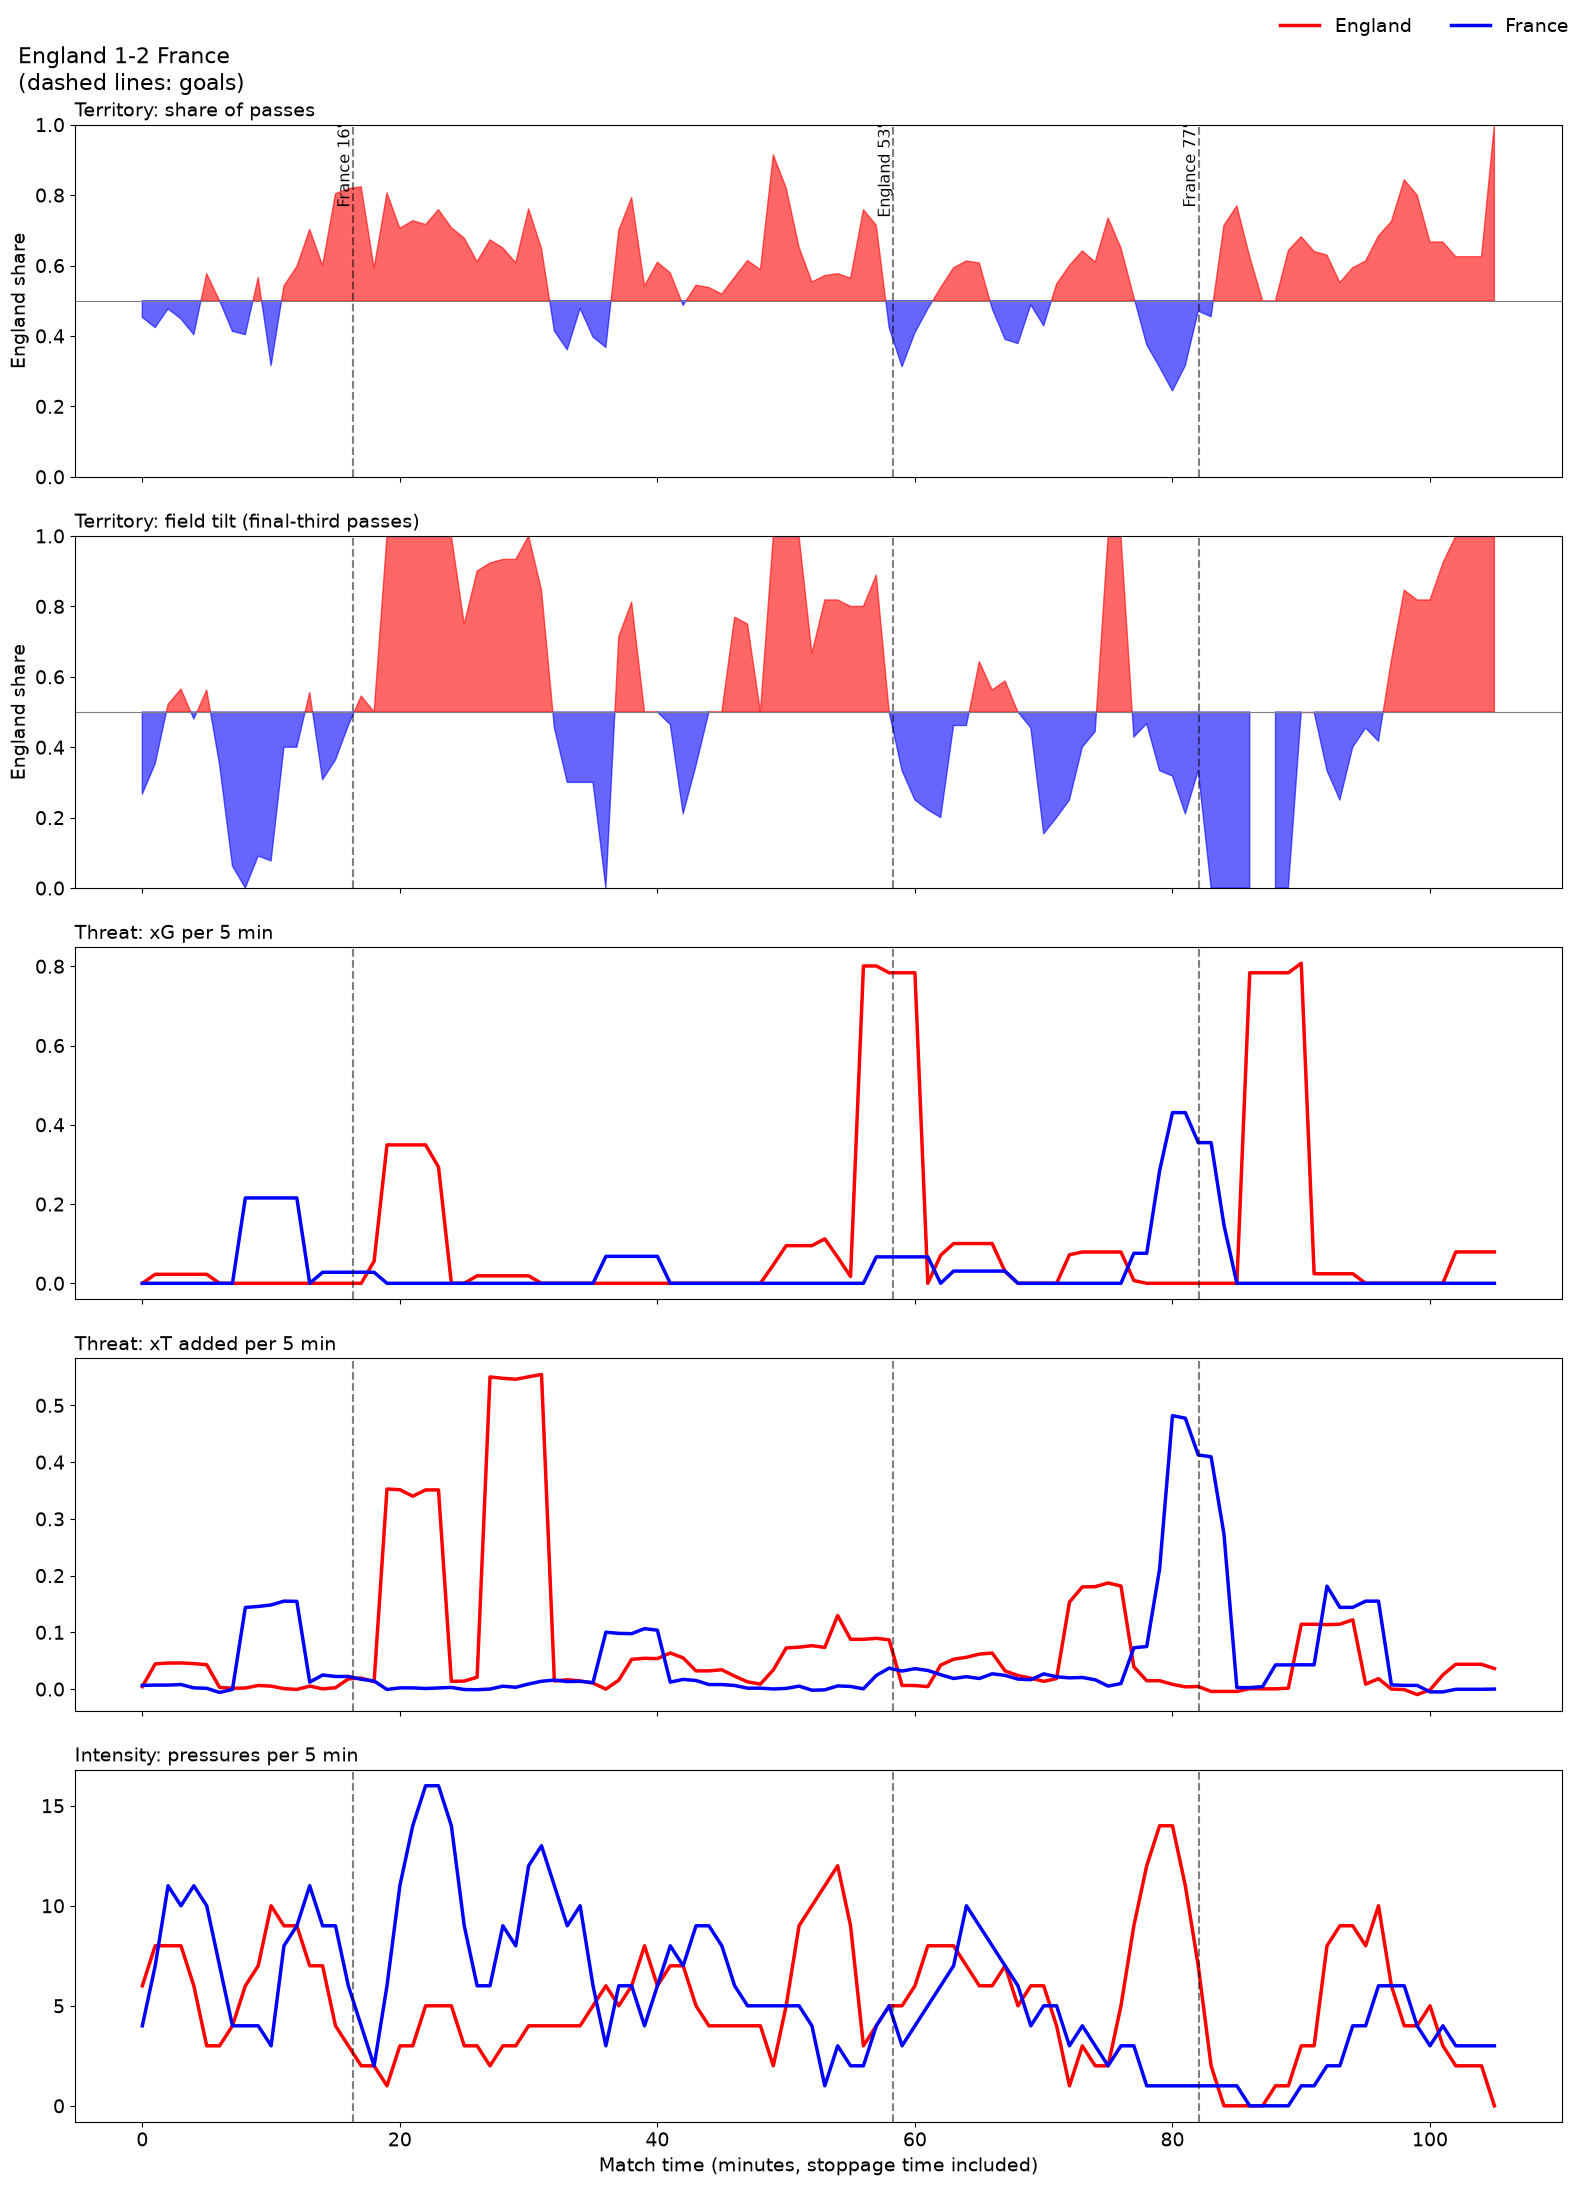

In [35]:
def match_dashboard(ev, tab, match_id, title, filename, window=5):
    m = tab.loc[match_id]
    teams = list(m.index.get_level_values(0).unique())
    colour = {t: team_colours.get(t, "grey") for t in teams}
    goals = ev[(ev["match_id"] == match_id) & (ev["type"] == "Shot") & (ev["shot_outcome"] == "Goal")]
    shares = {c: share(tab.loc[[match_id]], c, window).loc[match_id]
              for c in ("passes", "final_third_passes")}

    panels = [
                ("Territory: share of passes", shares["passes"], True),
                ("Territory: field tilt (final-third passes)", shares["final_third_passes"], True),
                (f"Threat: xG per {window} min", m["xg"], False),
                (f"Threat: xT added per {window} min", m["xt"], False),
                (f"Intensity: pressures per {window} min", m["pressures"], False),
    ]

    fig02, axs02 = plt.subplots(5, 1, sharex=True, sharey=False, figsize=(16, 22))
    fontssize = 16
    for ax, (panel_title, series, is_share) in zip(axs02, panels):
        if is_share:
            s = series.loc[teams[0]]
            ax.fill_between(s.index, 0.5, s, where=s >= 0.5, interpolate=True, alpha=0.6,
                            color=colour[teams[0]], label=teams[0])
            ax.fill_between(s.index, 0.5, s, where=s < 0.5, interpolate=True, alpha=0.6,
                            color=colour[teams[1]], label=teams[1])
            ax.axhline(0.5, color="grey", lw=0.8)
            ax.set_ylim(0, 1)
            ax.set_ylabel(f"{teams[0]} share")
        else:
            for team in teams:
                s = series.loc[team].rolling(window, center=True, min_periods=1).sum()
                ax.plot(s.index, s, lw=2.5, color=colour[team], label=team)
        ax.set_title(panel_title, loc="left")

        # goals as dashed lines on every panel
        for t in goals["t"]:
            ax.axvline(t, color="black", ls="--", alpha=0.5, lw=1.5)

    # one legend for the whole figure, instead of one per panel
    handles, labels = axs02[-1].get_legend_handles_labels()
    fig02.legend(handles, labels, loc="upper right", ncol=2, frameon=False)

    for t, lab in zip(goals["t"], goals["team"] + " " + goals["minute"].astype(str) + "'"):
        axs02[0].annotate(lab, (t, 1), rotation=90, va="top", ha="right", color="black",
                          fontsize=fontssize * 0.7)

    plt.rcParams.update({
        "font.size": fontssize,
        "axes.titlesize": fontssize,
        "axes.labelsize": fontssize,
        "xtick.labelsize": fontssize,
        "ytick.labelsize": fontssize,
        "legend.fontsize": fontssize,
        "legend.title_fontsize": fontssize,
        "figure.titlesize": fontssize,
    })

    axs02[-1].set_xlabel("Match time (minutes, stoppage time included)")
    fig02.suptitle(f"{title}\n(dashed lines: goals)", x=0.02, ha="left")
    fig02.tight_layout()
    fig02.savefig(out_/filename, dpi=150, bbox_inches="tight")
    plt.show()


match_dashboard(ev, tab, eng_fra_id, "England 1-2 France", "1b_england_france_dashboard.png")

## 7. Do the definitions agree?

For each measure we take team-minus-opponent over a 5-minute window, across every team in all 64 matches, and compute the Spearman correlation between measures. If "momentum" were one thing, all these would be strongly correlated. They aren't: possession barely tracks threat.

(We use a difference rather than a share because xT added can be negative, which makes a share meaningless.)

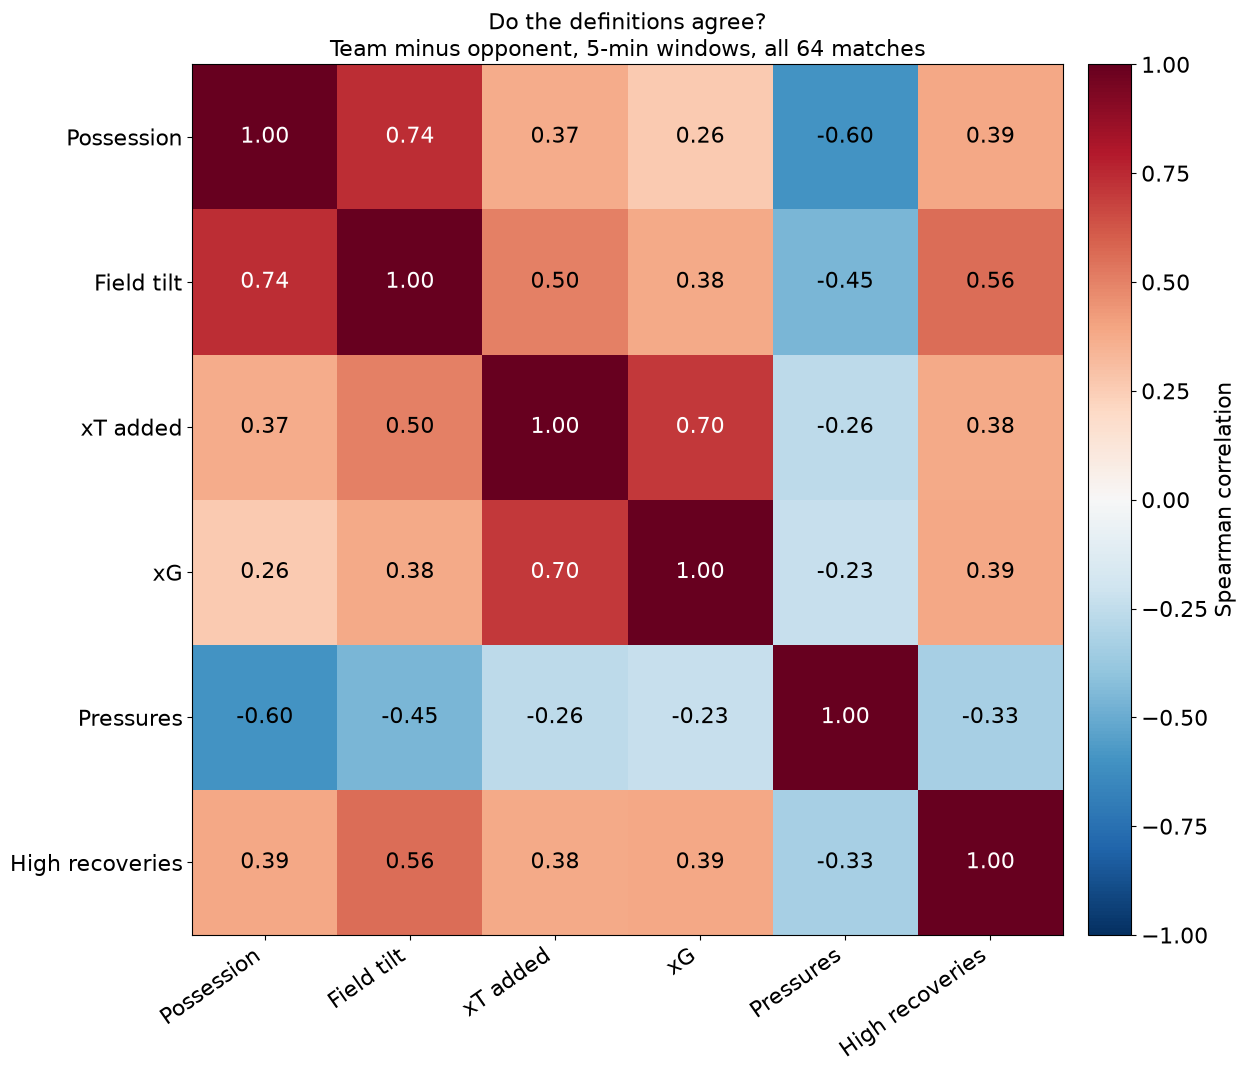

In [36]:
def fig_definition_agreement(tab, window=5):
    cols = ["passes", "final_third_passes", "xt", "xg", "pressures", "high_recoveries"]
    names = ["Possession", "Field tilt", "xT added", "xG", "Pressures", "High recoveries"]

    def diff(col):
        roll = tab[col].groupby(level=[0, 1]).transform(
            lambda s: s.rolling(window, center=True, min_periods=1).sum())
        return roll - (roll.groupby(level=[0, 2]).transform("sum") - roll)

    df = pd.DataFrame({n: diff(c) for c, n in zip(cols, names)})
    corr = df.corr(method="spearman")

    fig03, axs03 = plt.subplots(1, 1, sharex=False, sharey=False, figsize=(13, 11))

    im = axs03.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    axs03.set_xticks(range(len(names)), names, rotation=35, ha="right")
    axs03.set_yticks(range(len(names)), names)

    # correlation value written in each square, white on the dark ones so it stays readable
    for i in range(len(names)):
        for j in range(len(names)):
            value = corr.iloc[i, j]
            axs03.text(j, i, f"{value:.2f}", ha="center", va="center",
                       color="white" if abs(value) > 0.65 else "black")

    # colour bar attached to the plot, so it is exactly as tall as the grid
    divider = make_axes_locatable(axs03)
    cax = divider.append_axes("right", size="5%", pad=0.25)
    fig03.colorbar(im, cax=cax, label="Spearman correlation")
## 8. Dynamics: do shots cluster? (Monte Carlo)

If momentum is real, a team's shots should come in bursts. We measure the fraction of a team's shots that come within 5 minutes of its previous shot.

But random timing also produces bursts, so we need a baseline. The **null model** keeps each team's number of shots in each match but scatters them uniformly at random over the match: a world with no momentum. We simulate that 2,000 times and see where the real value falls.

- Only one shot per possession counts, so a rebound straight after a save isn't mistaken for momentum.
- Penalties are excluded.
- The p-value is the share of simulations at least as clustered as reality (with the usual +1 correction).
    axs03.set_title(f"Do the definitions agree?\nTeam minus opponent, {window}-min windows, all 64 matches")
    fig03.tight_layout()
    fig03.savefig(out_/"3_definition_agreement.png", dpi=150, bbox_inches="tight")
    plt.show()
    return corr


corr = fig_definition_agreement(tab)

## 8. Dynamics: do shots cluster? (Monte Carlo)

If momentum is real, a team's shots should come in bursts. We measure the fraction of a team's shots that come within 5 minutes of its previous shot.

But random timing also produces bursts, so we need a baseline. The **null model** keeps each team's number of shots in each match but scatters them uniformly at random over the match: a world with no momentum. We simulate that 2,000 times and see where the real value falls.

- Only one shot per possession counts, so a rebound straight after a save isn't mistaken for momentum.
- Penalties are excluded.
- The p-value is the share of simulations at least as clustered as reality (with the usual +1 correction).

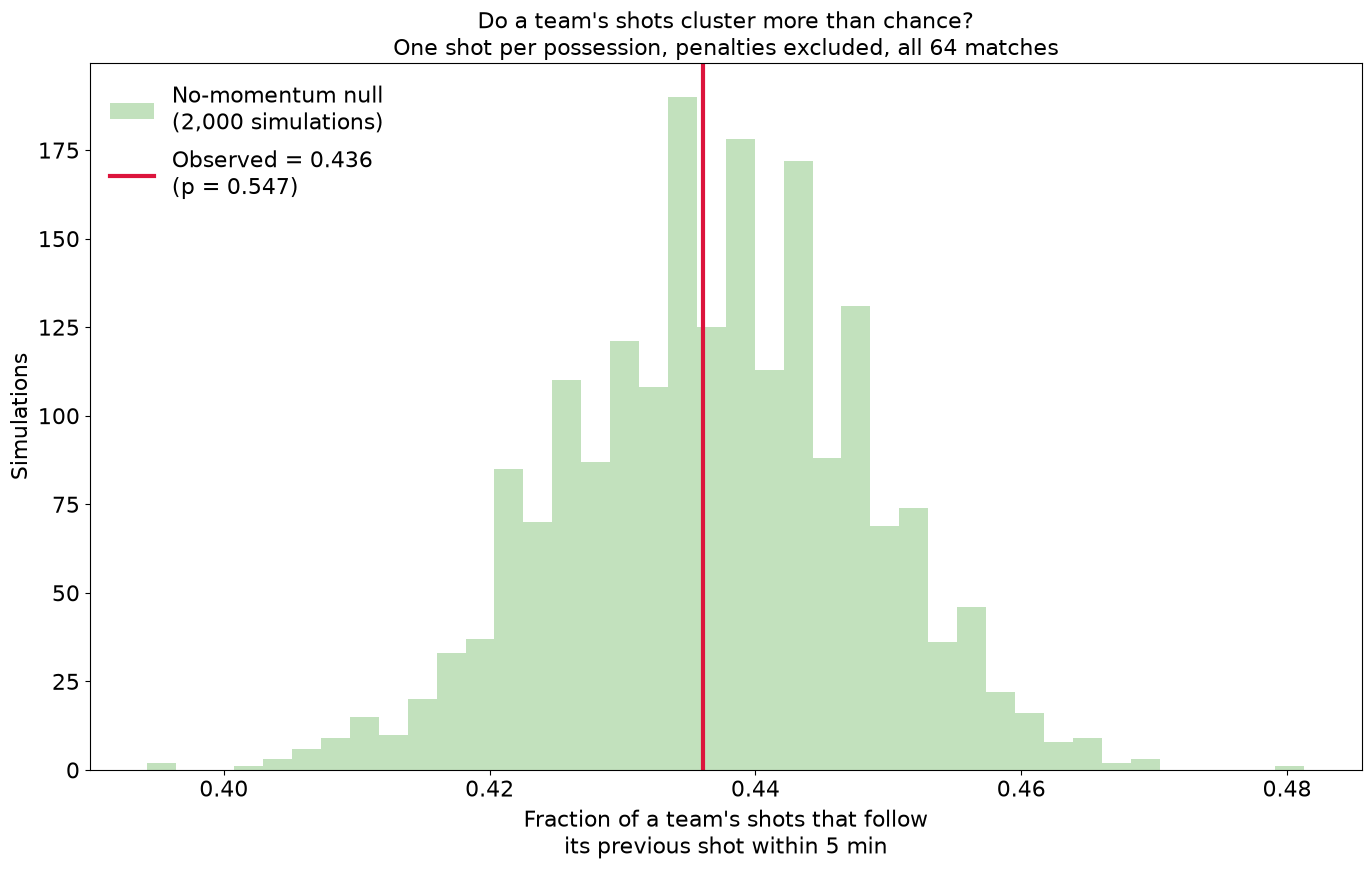

Shot clustering: observed 0.436, Monte Carlo p = 0.547


In [44]:
def fig_shot_clustering(ev, n_sims=2000, gap=5.0):
    shots = (ev[(ev["type"] == "Shot") & (ev["shot_type"] != "Penalty")]
             .drop_duplicates(["match_id", "possession"]))
    lengths = ev.groupby("match_id")["t"].max()

    def clustered_fraction(groups):
        hits = total = 0
        for times in groups:
            if len(times) < 2:
                continue
            gaps = np.diff(np.sort(times))
            hits += (gaps <= gap).sum()
            total += len(gaps)
        return hits / total

    grouped = shots.groupby(["match_id", "team"])
    groups = [g["t"].values for _, g in grouped]
    L = [lengths[mid] for (mid, _), _ in grouped]

    observed = clustered_fraction(groups)
    null = np.array([clustered_fraction([rng_.uniform(0, l, len(g)) for g, l in zip(groups, L)]) for _ in range(n_sims)])
    p = (np.sum(null >= observed) + 1)/(n_sims + 1)

    fig04, axs04 = plt.subplots(1, 1, sharex=False, sharey=False, figsize=(14, 9))

    axs04.hist(null, bins=40, color="#A8D5A2", alpha=0.7, label=f"No-momentum null\n({n_sims:,} simulations)")
    axs04.axvline(observed, color="crimson", lw=3, label=f"Observed = {observed:.3f}\n(p = {p:.3f})")

    axs04.set_xlabel(f"Fraction of a team's shots that follow\nits previous shot within {gap:.0f} min")
    axs04.set_ylabel("Simulations")
    axs04.set_title("Do a team's shots cluster more than chance?\n"
                    "One shot per possession, penalties excluded, all 64 matches")
    axs04.legend(loc="upper left", frameon=False)
    fig04.tight_layout()
    fig04.savefig(out_/"4_shot_clustering_null.png", dpi=150, bbox_inches="tight")
    plt.show()
    return observed, p


obs, p = fig_shot_clustering(ev)
print(f"Shot clustering: observed {obs:.3f}, Monte Carlo p = {p:.3f}")

## 9. Dynamics: does threat persist?

Another angle: if a team is dangerous this minute, is it still dangerous a few minutes later? That's the **autocorrelation** of xT added per minute at lags of 1 to 15 minutes, pooled over every team in every match.

For a baseline, we shuffle the order of minutes within each team's match 200 times. Shuffling destroys any memory, so the grey band shows what "no persistence" looks like.

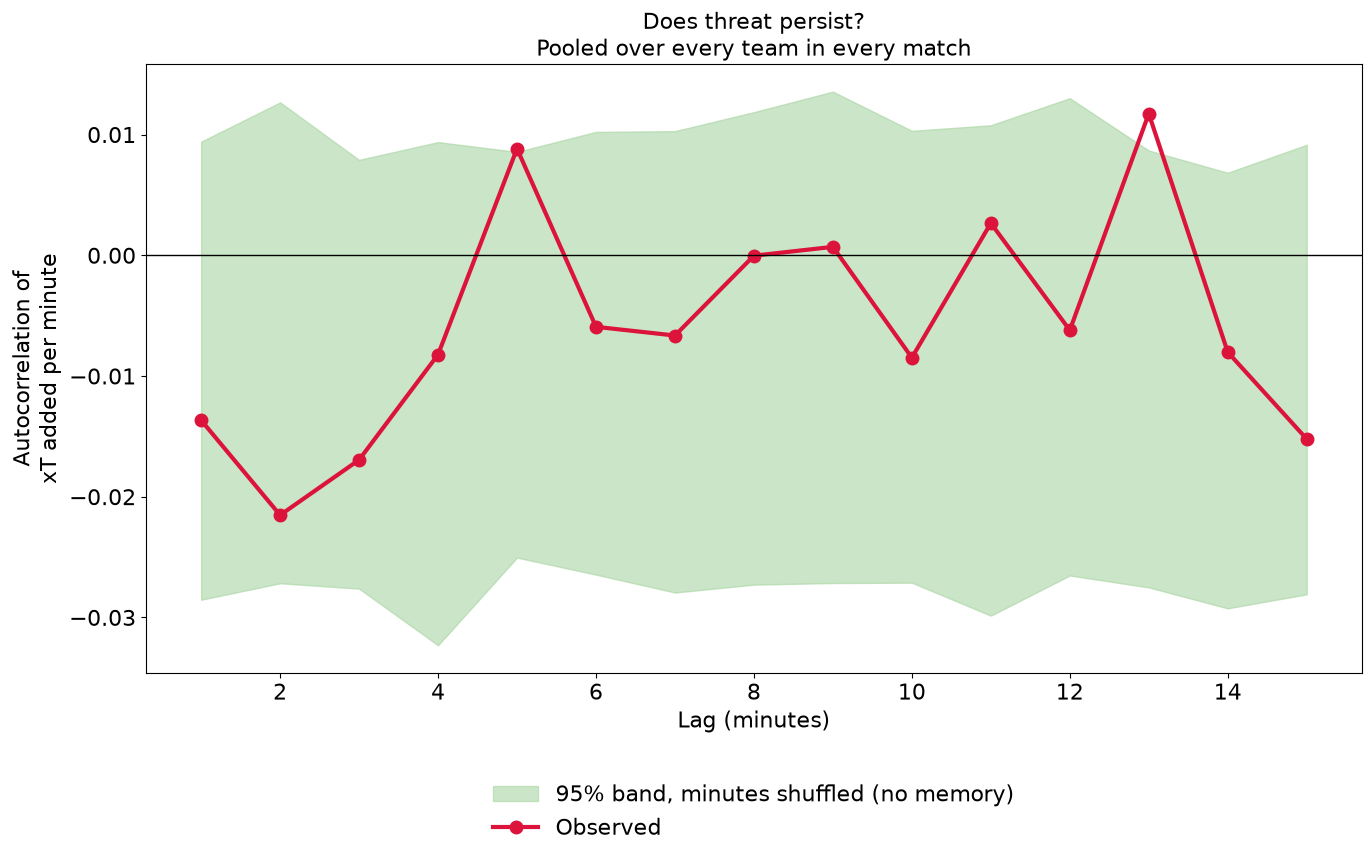

In [39]:
def fig_autocorrelation(tab, max_lag=15, n_perm=200):
    series = [g.values for _, g in tab["xt"].groupby(level=[0, 1])]

    def pooled_acf(seqs):
        out = []
        for lag in range(1, max_lag+1):
            a = np.concatenate([s[:-lag] - s.mean() for s in seqs])
            b = np.concatenate([s[lag:] - s.mean() for s in seqs])
            out.append(np.sum(a*b)/np.sqrt(np.sum(a*a)*np.sum(b*b)))
        return np.array(out)

    obs = pooled_acf(series)
    perm = np.array([pooled_acf([rng_.permutation(s) for s in series]) for _ in range(n_perm)])
    lo, hi = np.percentile(perm, [2.5, 97.5], axis=0)
    lags = np.arange(1, max_lag + 1)

    fig05, axs05 = plt.subplots(1, 1, sharex=False, sharey=False, figsize=(14, 9))

    axs05.fill_between(lags, lo, hi, color="#A8D5A2", alpha=0.6,
                       label="95% band, minutes shuffled (no memory)")
    axs05.plot(lags, obs, "o-", color="crimson", lw=3, ms=9, label="Observed")
    axs05.axhline(0, color="black", lw=1)

    axs05.set_xlabel("Lag (minutes)")
    axs05.set_ylabel("Autocorrelation of\nxT added per minute")
    axs05.set_title("Does threat persist?\nPooled over every team in every match")
    # legend below the plot so it doesn't cover the band
    axs05.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), frameon=False)
    fig05.tight_layout()
    fig05.savefig(out_/"5_threat_autocorrelation.png", dpi=150, bbox_inches="tight")
    plt.show()
    return obs


acf = fig_autocorrelation(tab)

## 10. Outcomes: what happens after a goal?

An **event study**: line up every goal at minute 0 and average the xT added per minute by the scoring team and the conceding team, 15 minutes either side. The shaded bands are ±1.96 standard errors (roughly 95% confidence).

If goals gave you momentum, the scorer's line would rise afterwards. Instead the scorer tends to sit back and the conceding team pushes forward.

Own goals are recorded by statsbomb as a separate event type, not as shots, so they aren't included.

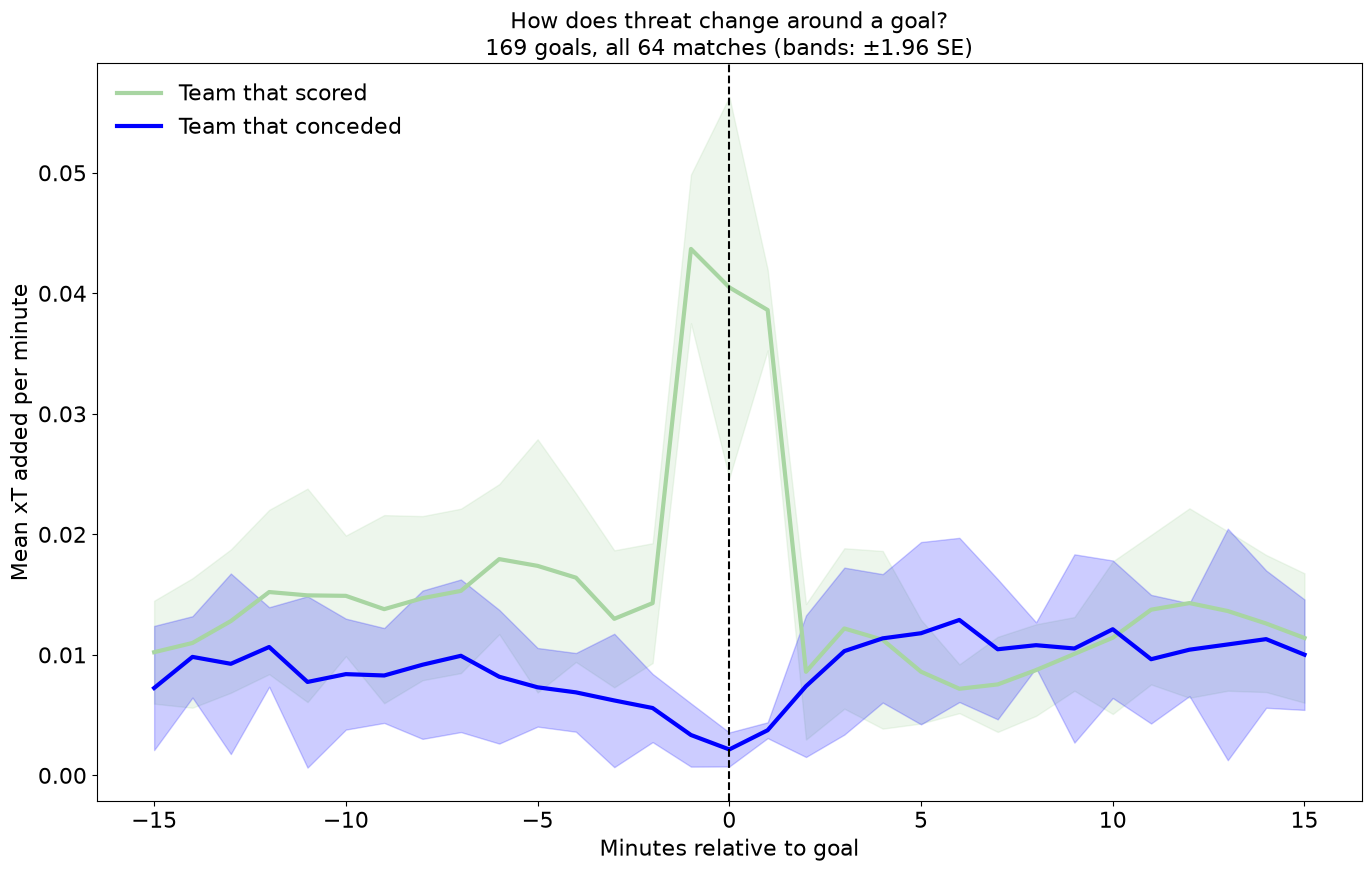

In [41]:
def fig_goal_event_study(ev, tab, span=15):
    goals = ev[(ev["type"] == "Shot") & (ev["shot_outcome"] == "Goal")]
    rel = np.arange(-span, span + 1)
    scorer, conceder = [], []
    for _, g in goals.iterrows():
        m = tab.loc[g["match_id"]]["xt"]
        teams = m.index.get_level_values(0).unique()
        opp = [t for t in teams if t != g["team"]][0]
        mins = int(g["t"]) + rel
        valid = (mins >= 0) & (mins <= m.index.get_level_values(1).max())
        s = pd.Series(np.nan, index=rel)
        c = pd.Series(np.nan, index=rel)
        s[valid] = m.loc[g["team"]].reindex(mins[valid]).values
        c[valid] = m.loc[opp].reindex(mins[valid]).values
        scorer.append(s)
        conceder.append(c)
    s, c = pd.concat(scorer, axis=1), pd.concat(conceder, axis=1)

    fig06, axs06 = plt.subplots(1, 1, sharex=False, sharey=False, figsize=(14, 9))

    for data, lab, col in ((s, "Team that scored", "#A8D5A2"), (c, "Team that conceded", "b")):
        mean = data.mean(axis=1).rolling(3, center=True, min_periods=1).mean()
        se = data.std(axis=1)/np.sqrt(data.notna().sum(axis=1))
        axs06.plot(rel, mean, lw=3, color=col, label=lab)
        axs06.fill_between(rel, mean - 1.96 * se, mean + 1.96 * se, color=col, alpha=0.2)

    axs06.axvline(0, color="black", ls="--", lw=1.5)
    axs06.set_xlabel("Minutes relative to goal")
    axs06.set_ylabel("Mean xT added per minute")
    axs06.set_title(f"How does threat change around a goal?\n"
                    f"{len(goals)} goals, all 64 matches (bands: ±1.96 SE)")
    axs06.legend(loc="upper left", frameon=False)
    fig06.tight_layout()
    fig06.savefig(out_/"6_goal_event_study.png", dpi=150, bbox_inches="tight")
    plt.show()


fig_goal_event_study(ev, tab)

## The momentum graph

Finally, the thing that started all this: a broadcast-style momentum graph. Each bar is the difference
in threat between the two teams (xT added plus xG) in that minute, smoothed so it doesn't jump about.
Red bars mean England are on top, blue bars mean France are.

Unlike the dashboard, the smoothing here only looks backwards, so this is a graph you could actually
draw live. I still have no idea how this is done in real time. 

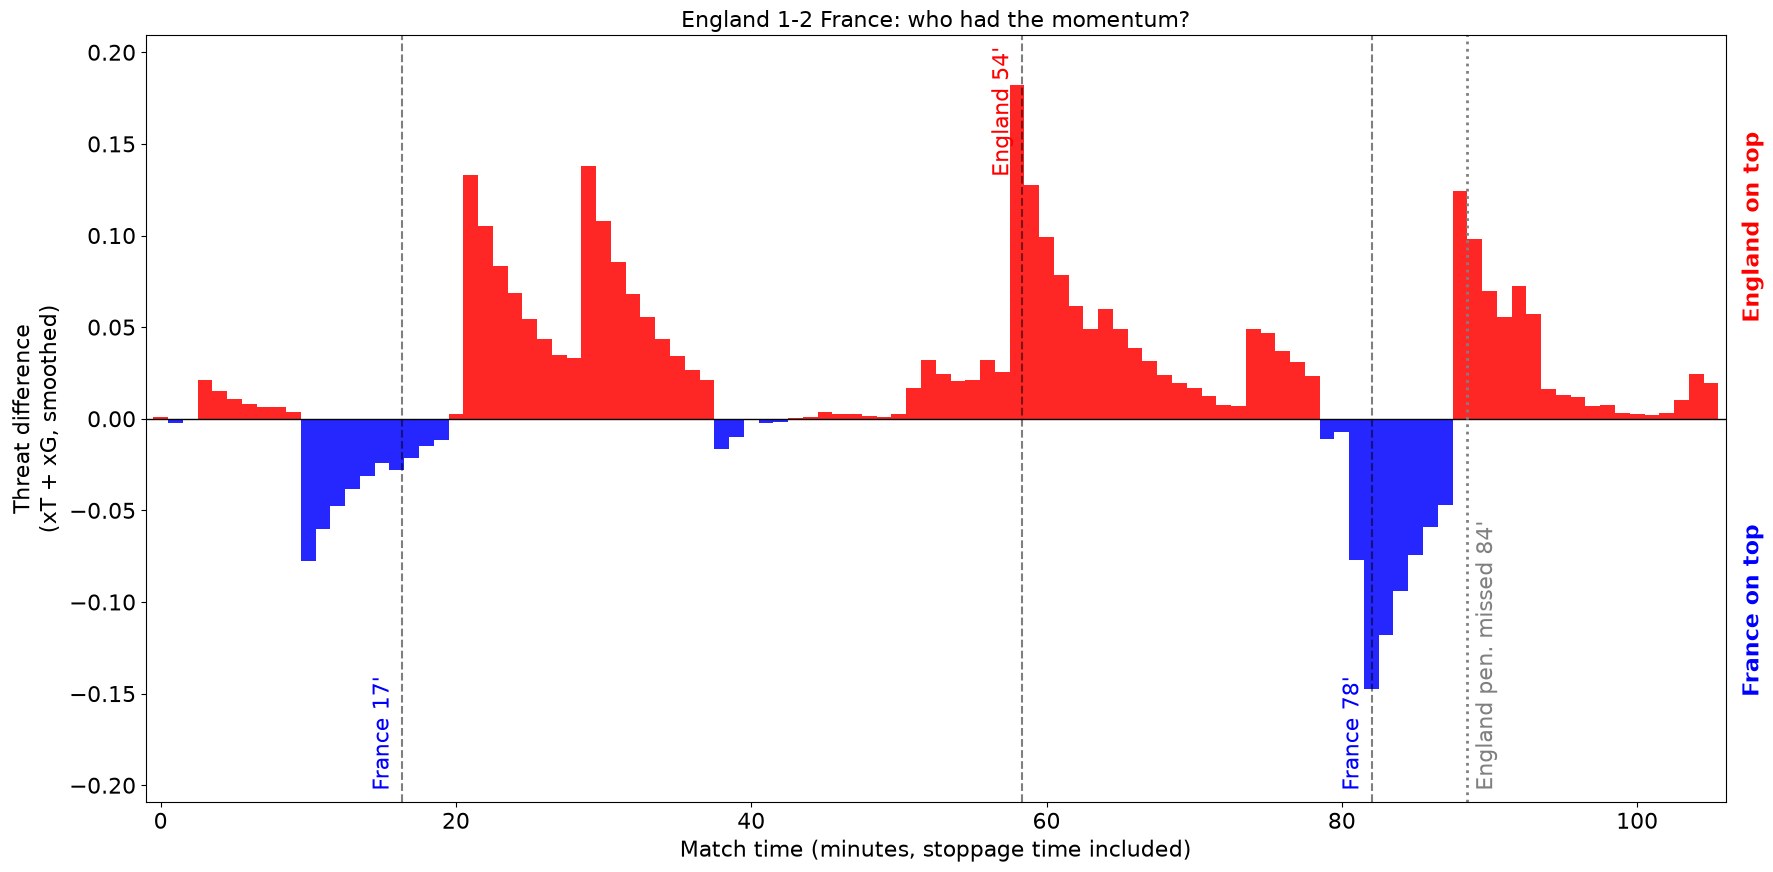

In [43]:
def fig_momentum(ev, tab, match_id, home, away, title, filename, halflife=3):
    m = tab.loc[match_id]

    # threat per minute = possession value added (xT) + quality of chances (xG)
    threat = m["xt"] + m["xg"]
    diff = threat.loc[home] - threat.loc[away]

    # exponentially weighted average: only looks backwards, so a live graph could draw it
    momentum = diff.ewm(halflife=halflife).mean()

    goals = ev[(ev["match_id"] == match_id) & (ev["type"] == "Shot") & (ev["shot_outcome"] == "Goal")]
    pens = ev[(ev["match_id"] == match_id) & (ev["type"] == "Shot") & (ev["shot_type"] == "Penalty")]

    fig07, axs07 = plt.subplots(1, 1, sharex=False, sharey=False, figsize=(18, 9))

    colours = np.where(momentum >= 0, team_colours[home], team_colours[away])
    axs07.bar(momentum.index, momentum.values, width=1.0, color=colours, alpha=0.85)
    axs07.axhline(0, color="black", lw=1)

    # symmetric y-axis so neither team looks bigger by default
    lim = 1.15 * np.abs(momentum).max()
    axs07.set_ylim(-lim, lim)

    # goals: dashed lines, labelled on the scoring team's side (minute + 1 = TV clock)
    for _, g in goals.iterrows():
        axs07.axvline(g["t"], color="black", ls="--", alpha=0.5, lw=1.5)
        y = 0.97 * lim if g["team"] == home else -0.97 * lim
        axs07.annotate(f"{g['team']} {g['minute'] + 1}'", (g["t"], y), xytext=(-6, 0),
                       textcoords="offset points", rotation=90, ha="right",
                       va="top" if g["team"] == home else "bottom", color=team_colours[g["team"]])

    # missed penalties: dotted grey lines
    for _, pk in pens[pens["shot_outcome"] != "Goal"].iterrows():
        axs07.axvline(pk["t"], color="grey", ls=":", lw=2)
        axs07.annotate(f"{pk['team']} pen. missed {pk['minute'] + 1}'", (pk["t"], -0.97 * lim),
                       xytext=(6, 0), textcoords="offset points", rotation=90, ha="left",
                       va="bottom", color="grey")

    # which team is which side, written outside the plot on the right
    axs07.text(1.01, 0.75, f"{home} on top", transform=axs07.transAxes, rotation=90,
               va="center", ha="left", color=team_colours[home], fontweight="bold")
    axs07.text(1.01, 0.25, f"{away} on top", transform=axs07.transAxes, rotation=90,
               va="center", ha="left", color=team_colours[away], fontweight="bold")

    axs07.set_xlabel("Match time (minutes, stoppage time included)")
    axs07.set_ylabel("Threat difference\n(xT + xG, smoothed)")
    axs07.set_title(title)
    axs07.set_xlim(-1, momentum.index.max() + 1)
    fig07.tight_layout()
    fig07.savefig(out_/filename, dpi=150, bbox_inches="tight")
    plt.show()
    return momentum


momentum = fig_momentum(ev, tab, eng_fra_id, "England", "France",
                        "England 1-2 France: who had the momentum?", "7_england_france_momentum.png")

## So what actually happened in England v France?

**England had the ball, France had the moments.** For most of the match England were on top by
every territorial measure. After France's opener in the 16th minute, England had 60 to 80% of the
passes and, for long spells, almost all of the final-third passes. If you'd only looked at a
broadcast momentum graph, you'd have backed England.

**But England's threat came in bursts, not waves.** Their big xT spikes came in the first half, mostly
from corners and crosses, and their two biggest xG spikes were both penalties. Take those away and
the chances were roughly level. France didn't need much: a strike from distance for the opener, then
one quick attack around the 77th minute, a cross and Giroud's header, which was their biggest threat
of the whole game.

**It looks like score effects, not momentum.** (is it surprising) After each France goal, England pushed forward and
France sat deeper, just like the tournament-wide goal study shows: the team that concedes chases, and
the team that scores drops off. France's pressing also rose while England had the ball in the first
half, which fits the negative link between possession and pressing in the correlation grid.

**The bigger picture.** Across all 64 matches, shots don't cluster more than chance and threat in one
minute tells you almost nothing about the next. So England's spells of pressure weren't building
towards anything. They were England having the ball in areas that, as the xT map shows, are
mostly worth very little. France made their few trips into the bright squares count, and England
sent one of theirs over the bar.

## Summary

- **The measures disagree.** Possession, field tilt, threat and pressing tell different stories about who is "on top".
- **Shots don't cluster** more than a no-momentum simulation would produce.
- **Threat barely persists** beyond what shuffled minutes give you.
- **After a goal, the scorer tends to sit back** and the conceding team pushes on.

## Future work

- **A forward-looking model:** no centred smoothing, a Hawkes (self-exciting) process, a scoreline-aware baseline, and more data.
- **Premier League data:** apply the same approach to a full league season (StatsBomb's free data includes 2015/16, shame it doesn't have latest seasons). There's much more data and so much to unpack!

*Data: [StatsBomb open data](https://github.com/statsbomb/open-data).*